In [1]:
model_checkpoint = "microsoft/swin-tiny-patch4-window7-224" 
batch_size = 32 

In [2]:
from datasets import load_dataset 


/home/cc1/miniconda3/envs/pt/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import evaluate

metric = evaluate.load("accuracy")

In [4]:
dataset = load_dataset("imagefolder", data_dir="/home/cc1/Documents/Code/AIO-IDS/data/image_cicids2017/train_224")

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 80754
    })
})

In [6]:
example = dataset["train"][10]
example

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>,
 'label': 0}

In [7]:
dataset["train"].features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['0', '10', '11', '2', '3', '4', '5', '6', '7'], id=None)}

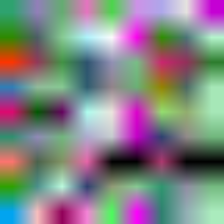

In [8]:
example['image']

In [9]:
from transformers import AutoImageProcessor

image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor 

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [10]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
if "height" in image_processor.size:
    size = (image_processor.size["height"], image_processor.size["width"])
    crop_size = size
    max_size = None
elif "shortest_edge" in image_processor.size:
    size = image_processor.size["shortest_edge"]
    crop_size = (size, size)
    max_size = image_processor.size.get("longest_edge")

train_transforms = Compose(
        [
            RandomResizedCrop(crop_size),
            RandomHorizontalFlip(),
            ToTensor(),
            normalize,
        ]
    )

val_transforms = Compose(
        [
            Resize(size),
            CenterCrop(crop_size),
            ToTensor(),
            normalize,
        ]
    )

def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in example_batch["image"]
    ]
    return example_batch

def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

In [11]:
splits = dataset["train"].train_test_split(test_size=0.1)
train_ds = splits['train']
val_ds = splits['test']

In [12]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[2]

'11'

In [13]:
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [14]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint, 
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes = True,
)

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([9]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([9, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
    f"{model_name}-finetuned-eurosat",
    remove_unused_columns=False,
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=64,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

/home/cc1/miniconda3/envs/pt/lib/python3.9/site-packages/transformers/training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [16]:
import numpy as np

def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [17]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [18]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

/tmp/ipykernel_32174/850056282.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [19]:
train_results = trainer.train()

trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

  1%|          | 10/852 [00:16<22:00,  1.57s/it]

{'loss': 9.2162, 'grad_norm': 55.65856170654297, 'learning_rate': 5.8139534883720935e-06, 'epoch': 0.04}


  2%|▏         | 20/852 [00:32<22:05,  1.59s/it]

{'loss': 6.6008, 'grad_norm': 38.6608772277832, 'learning_rate': 1.1627906976744187e-05, 'epoch': 0.07}


  4%|▎         | 30/852 [00:47<21:39,  1.58s/it]

...

{'loss': 0.0002, 'grad_norm': 0.08532573282718658, 'learning_rate': 1.3054830287206266e-07, 'epoch': 2.99}


                                                 
100%|██████████| 852/852 [23:48<00:00,  1.52s/it]

{'eval_loss': 7.155055072871619e-07, 'eval_accuracy': 1.0, 'eval_runtime': 23.29, 'eval_samples_per_second': 346.758, 'eval_steps_per_second': 5.453, 'epoch': 3.0}


100%|██████████| 852/852 [23:49<00:00,  1.68s/it]

{'train_runtime': 1429.2734, 'train_samples_per_second': 152.549, 'train_steps_per_second': 0.596, 'train_loss': 0.2592891997015536, 'epoch': 3.0}
***** train metrics *****
  epoch                    =          3.0
  total_flos               = 5048244008GF
  train_loss               =       0.2593
  train_runtime            =   0:23:49.27
  train_samples_per_second =      152.549
  train_steps_per_second   =        0.596


In [20]:
metrics = trainer.evaluate()
# some nice to haves:
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

100%|██████████| 127/127 [00:23<00:00,  5.47it/s]

***** eval metrics *****
  epoch                   =        3.0
  eval_accuracy           =        1.0
  eval_loss               =        0.0
  eval_runtime            = 0:00:23.50
  eval_samples_per_second =    343.587
  eval_steps_per_second   =      5.403
